## Diabetes Predictions

### Import Requirement Library 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### import the dataset Library 

In [2]:
from sklearn.datasets import load_diabetes

### Load Dataset  from load_diabetes

In [3]:
dataset=load_diabetes()

### Description of the data

In [4]:
print(dataset['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

### Create DataFrame and insert the diabetes data

In [5]:
import pandas as pd
df_diabetes=pd.DataFrame(dataset.data,columns=['age','sex','bmi','bp','s1','s2','s3','s4','s5','s6'])
df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


### Independent and Dependent Features 

In [7]:
## Independent and dependent features 
x=df_diabetes
y=dataset['target']

### Split the train test split dataset

In [8]:
## Split the train test split 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

### Check the correlation of dataset in data columns 

In [9]:
## Check the correlation 
x_train.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.136522,0.181976,0.308406,0.261534,0.200301,-0.023100,0.165340,0.270981,0.262201
sex,0.136522,1.000000,0.044746,0.165128,0.033717,0.128023,-0.344052,0.320619,0.121299,0.159936
bmi,0.181976,0.044746,1.000000,0.384534,0.246802,0.255519,-0.372335,0.431946,0.448657,0.394699
bp,0.308406,0.165128,0.384534,1.000000,0.242052,0.164355,-0.113747,0.209316,0.362476,0.376421
s1,0.261534,0.033717,0.246802,0.242052,1.000000,0.891476,0.044128,0.556987,0.528922,0.323666
s2,0.200301,0.128023,0.255519,0.164355,0.891476,1.000000,-0.190767,0.653120,0.307541,0.298647
s3,-0.023100,-0.344052,-0.372335,-0.113747,0.044128,-0.190767,1.000000,-0.732862,-0.388778,-0.304091
s4,0.165340,0.320619,0.431946,0.209316,0.556987,0.653120,-0.732862,1.000000,0.629707,0.441489
s5,0.270981,0.121299,0.448657,0.362476,0.528922,0.307541,-0.388778,0.629707,1.000000,0.464878
s6,0.262201,0.159936,0.394699,0.376421,0.323666,0.298647,-0.304091,0.441489,0.464878,1.000000


### visualize the correlation in graphical way using seaborn 


<Axes: >

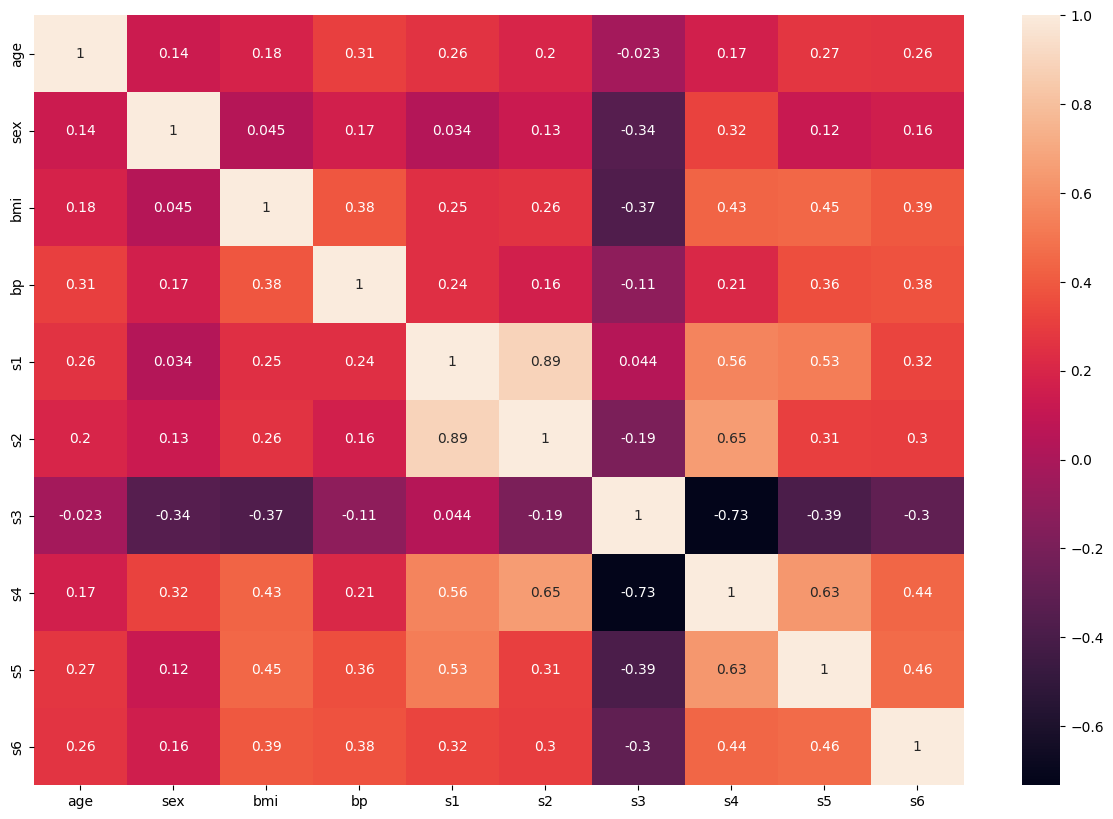

In [10]:
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(x_train.corr(),annot=True)

## Create Model Decision Tree Regression 


In [11]:
from sklearn.tree import DecisionTreeRegressor
regressor=DecisionTreeRegressor(max_depth=3,max_features=10)
regressor.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,10
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Hyperparameter Tuning

In [14]:
from sklearn.model_selection import GridSearchCV
params={
    'criterion':['squared_error','friedman_mse','absolute_error'],
    'splitter':['best','random'],
    'max_depth':[i for i in range(1 , 26, 3)],
    'max_features':['auto','sqrt','log2']
}

In [15]:
params

{'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
 'splitter': ['best', 'random'],
 'max_depth': [1, 4, 7, 10, 13, 16, 19, 22, 25],
 'max_features': ['auto', 'sqrt', 'log2']}

In [16]:
regressor=DecisionTreeRegressor()

In [17]:
grid=GridSearchCV(regressor,param_grid=params,cv=5,scoring='neg_mean_squared_error')

In [18]:
regressor

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### Ignore the Warnings 

In [20]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(x_train,y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 4, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


### Best Params in the grid search 

In [21]:
grid.best_params_

{'criterion': 'squared_error',
 'max_depth': 4,
 'max_features': 'log2',
 'splitter': 'random'}

### Predicting the Model Score 

In [22]:
from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error
y_pred=grid.predict(x_test)
print('R2 Score : ',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
print('MSEW',mean_squared_error(y_test,y_pred))

R2 Score :  0.20881385481378978
MAE 53.65675519134166
MSEW 4271.066308655318


In [44]:
selectmodel=DecisionTreeRegressor(criterion='squared_error',max_depth=4,max_features='sqrt',splitter='random')
selectmodel.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'random'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [45]:
y_pred=selectmodel.predict(x_test)
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.13432516421852125
56.58255948812432
4673.179185268475


[Text(0.5, 0.9, 'x[4] <= -0.028\nsquared_error = 6148.282\nsamples = 309\nvalue = 153.903'),
 Text(0.25, 0.7, 'x[2] <= 0.057\nsquared_error = 6703.89\nsamples = 90\nvalue = 139.278'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'x[6] <= 0.051\nsquared_error = 4134.252\nsamples = 79\nvalue = 122.228'),
 Text(0.0625, 0.3, 'x[6] <= 0.023\nsquared_error = 4224.313\nsamples = 74\nvalue = 124.108'),
 Text(0.03125, 0.1, 'squared_error = 4362.718\nsamples = 67\nvalue = 128.403'),
 Text(0.09375, 0.1, 'squared_error = 1033.143\nsamples = 7\nvalue = 83.0'),
 Text(0.1875, 0.3, 'x[4] <= -0.043\nsquared_error = 1974.64\nsamples = 5\nvalue = 94.4'),
 Text(0.15625, 0.1, 'squared_error = 70.25\nsamples = 4\nvalue = 72.5'),
 Text(0.21875, 0.1, 'squared_error = 0.0\nsamples = 1\nvalue = 182.0'),
 Text(0.375, 0.5, 'x[9] <= 0.034\nsquared_error = 8076.926\nsamples = 11\nvalue = 261.727'),
 Text(0.3125, 0.3, 'x[2] <= 0.129\nsquared_error = 6904.49\nsamples = 7\nvalue = 267.714'),
 Text(0.28125, 0.1, 'squ

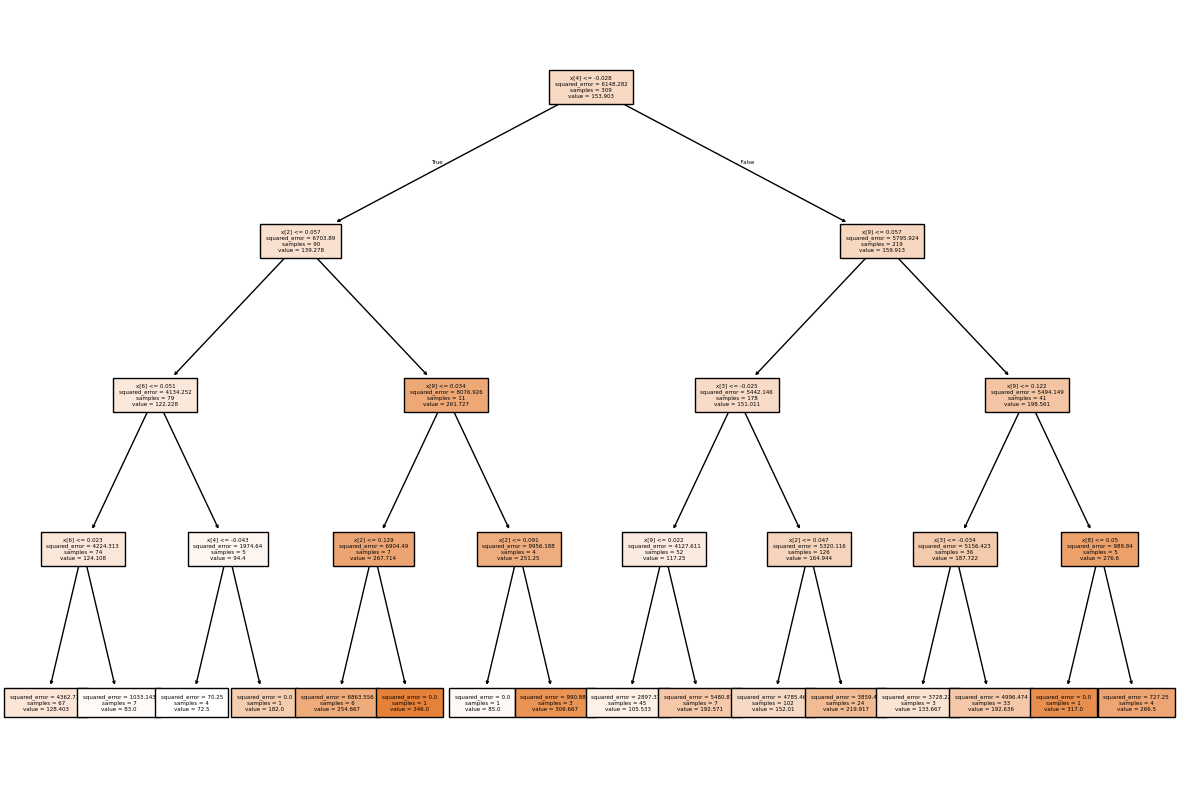

In [50]:
## Visualize the DecisionTree 
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(selectmodel,filled=True,fontsize=4)